# Sequential Workflow

In [1]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict

from langchain_groq import ChatGroq
from dotenv import load_dotenv
load_dotenv()

model= ChatGroq(model= "llama-3.1-8b-instant")

In [13]:
class BlogState(TypedDict):
    
    title: str
    outline: str
    content :str
    score:int

In [14]:
# create outline

def create_outline(state:BlogState)->BlogState:
    # fetch title
    title= state['title']
    
    prompt = f'Please generate detailed outline for a blog on following Topic {title}'
    # call ll to gen outline
    outline= model.invoke(prompt).content
    
    state['outline']= outline
    return state

In [15]:
# create blog

def create_blog(state:BlogState)->BlogState:
    title = state['title']
    outline = state['outline']
    
    prompt= f"Write a detailed blog on title -{title} using the following outline \n {outline}"
    
    blog = model.invoke(prompt).content
    
    state['content'] = blog
    
    return state

In [31]:
# create blog

def rate_my_blog(state:BlogState)->BlogState:
    title = state['title']
    outline = state['outline'],
    blog = state['content']
    
    prompt= f"Please rate me blog and give it a score out of 10, just an integer value nothing else, based on the title :- {title}, following outline \n {outline} and the blog body: \n {blog}"
    
    score = model.invoke(prompt).content
    
    state['score'] = score
    
    return state

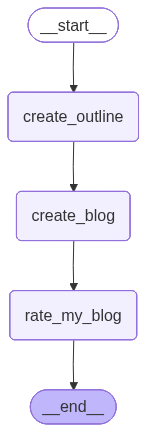

In [32]:
graph = StateGraph(BlogState)

graph.add_node('create_outline', create_outline)
graph.add_node('create_blog', create_blog)
graph.add_node('rate_my_blog', rate_my_blog)


graph.add_edge(START, "create_outline")
graph.add_edge("create_outline", "create_blog")
graph.add_edge("create_blog", 'rate_my_blog')
graph.add_edge("rate_my_blog", END)

graph.compile()



In [33]:
workflow= graph.compile()

In [34]:
initial_state= {'title': "Rise of AI in India"}

final_state = workflow.invoke(initial_state)

print(final_state)

{'title': 'Rise of AI in India', 'outline': "**Title:** The Rise of AI in India: Transforming the Country's Future\n\n**I. Introduction**\n\n* Brief overview of the importance of AI in the modern world\n* Background on India's growth and its potential in the AI sector\n* Thesis statement: The rise of AI in India is transforming the country's future, with significant potential for growth, innovation, and job creation.\n\n**II. The Current AI Landscape in India**\n\n* Overview of the AI ecosystem in India, including key players, startups, and research institutions\n* Analysis of the current AI adoption trends in various industries, such as:\n\t+ Healthcare\n\t+ Financial Services\n\t+ Education\n\t+ Manufacturing\n\t+ Retail\n* Discussion of the key challenges and opportunities facing the Indian AI sector\n\n**III. Government Initiatives and Policies Supporting AI Growth**\n\n* Overview of government initiatives and policies aimed at promoting AI growth in India, including:\n\t+ National

In [28]:
print(final_state['outline'])

**Title: The Rise of AI in India: Transforming the Country through Innovation**

**I. Introduction**

* Brief overview of Artificial Intelligence (AI) and its growing importance worldwide
* India's position in the global AI landscape
* Thesis statement: The rise of AI in India is revolutionizing various sectors, driving economic growth, and improving the quality of life for its citizens.

**II. Key Drivers of AI Adoption in India**

* Government initiatives:
 + National AI Portal (NAP)
 + AI for All program
 + Focus on digital India
* Private sector investments and collaborations
* Availability of skilled talent and research institutions
* Growing demand for automation and efficiency

**III. AI Applications in India across Various Sectors**

* **Healthcare:**
 + AI-powered diagnostic tools
 + Personalized medicine
 + Telemedicine and virtual consultations
* **Education:**
 + Intelligent tutoring systems
 + Adaptive learning platforms
 + AI-powered grading and assessment tools
* **Finan

In [29]:
print(final_state['content'])

**The Rise of AI in India: Transforming the Country through Innovation**

**I. Introduction**

Artificial Intelligence (AI) has been revolutionizing the way we live, work, and interact with each other. From virtual assistants to self-driving cars, AI has become an integral part of our daily lives. As the world becomes increasingly dependent on AI, India has emerged as a key player in the global AI landscape. With a growing population of tech-savvy individuals, a thriving startup ecosystem, and a government that is actively promoting AI adoption, India is poised to become a hub for AI innovation.

**Thesis statement:** The rise of AI in India is revolutionizing various sectors, driving economic growth, and improving the quality of life for its citizens.

India's position in the global AI landscape is unique. With a growing middle class, a large youth population, and a strong focus on digital transformation, India has the potential to become a leader in AI adoption. The country has made 

In [35]:
print(final_state['score'])

8
